<a href="https://colab.research.google.com/github/GEO-HACK/watchtower-ml/blob/main/notebooks/combined_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/'))

os.listdir('/content/drive/MyDrive/')

True


['Colab Notebooks',
 'TrafficLabelling ',
 'Medifund Revolutionizing Medical Crowdfunding.gslides',
 'School Id.jpg',
 'JOMO KENYATTA UNIVERSITY STUDENTS.docx',
 'AgroStats',
 'Untitled document (6).gdoc',
 'DIGISOKO PROJECT PROPOSAL .gdoc',
 'WhatsApp Image 2024-11-16 at 2.50.57 PM.jpeg',
 'Exam Scheduling.docx',
 'Untitled document (5).gdoc',
 'Untitled document (4).gdoc',
 'Assignemnt2GeoffreyKirumbaMbuguaSCT212-0137-2022.docx',
 'Copy of lecture2_relational model (1).ppt',
 'Copy of MS SQL Server Express 2019 installation guide.docx',
 'Copy of lecture1_introduction to databases.ppt',
 'Copy of lecture2_relational model.ppt',
 'Copy of Week 3 lab exercise.docx',
 'Copy of Introduction to SQL.pptx',
 'Copy of Joins and Views.pptx',
 'Copy of BCT 2304 Assignment 1.docx',
 'Copy of Aggregation_Group by and Totals.pptx',
 'Copy of wk 6 lab _sql scripts.pptx',
 'Copy of Week 5_Operands.pptx',
 'SHORT Documentation on “Teamwork”.gdoc',
 'Untitled document (3).gdoc',
 'basigo.gdoc',
 'res

In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/'))

os.listdir('/content/drive/MyDrive/')

True


['Colab Notebooks',
 'TrafficLabelling ',
 'Medifund Revolutionizing Medical Crowdfunding.gslides',
 'School Id.jpg',
 'JOMO KENYATTA UNIVERSITY STUDENTS.docx',
 'AgroStats',
 'Untitled document (6).gdoc',
 'DIGISOKO PROJECT PROPOSAL .gdoc',
 'WhatsApp Image 2024-11-16 at 2.50.57 PM.jpeg',
 'Exam Scheduling.docx',
 'Untitled document (5).gdoc',
 'Untitled document (4).gdoc',
 'Assignemnt2GeoffreyKirumbaMbuguaSCT212-0137-2022.docx',
 'Copy of lecture2_relational model (1).ppt',
 'Copy of MS SQL Server Express 2019 installation guide.docx',
 'Copy of lecture1_introduction to databases.ppt',
 'Copy of lecture2_relational model.ppt',
 'Copy of Week 3 lab exercise.docx',
 'Copy of Introduction to SQL.pptx',
 'Copy of Joins and Views.pptx',
 'Copy of BCT 2304 Assignment 1.docx',
 'Copy of Aggregation_Group by and Totals.pptx',
 'Copy of wk 6 lab _sql scripts.pptx',
 'Copy of Week 5_Operands.pptx',
 'SHORT Documentation on “Teamwork”.gdoc',
 'Untitled document (3).gdoc',
 'basigo.gdoc',
 'res

In [33]:


os.listdir('/content/drive/MyDrive/TrafficLabelling/')

['Monday-WorkingHours.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'Tuesday-WorkingHours.pcap_ISCX.csv',
 'Wednesday-workingHours.pcap_ISCX.csv',
 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']

In [29]:
from google.colab import drive
drive.mount('/content/drive' , force_remount=True)



Mounted at /content/drive


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


#Loading all the data


In [35]:
DATASET = '/content/drive/MyDrive/TrafficLabelling/'

# loading and concatenating all the datasets
all_files = [f for f in os.listdir(DATASET) if f.endswith('.csv')]
print(f"Found {len(all_files)} files: {all_files}")

dfs = []
for file in all_files:
  path = os.path.join(DATASET, file)
  df_temp = pd.read_csv(path, low_memory=False)
  df_temp['source_file'] = file #track which file each row came from
  dfs.append(df_temp)

print(f" {file} -shape: {df_temp.shape}")

df = pd.concat(dfs, ignore_index=True)
print(f"\ combined dataset shape: {df.shape}")

Found 6 files: ['Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']
 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -shape: (225745, 86)
\ combined dataset shape: (2371775, 86)


#initial exploration

In [36]:
print("=" * 60)
print("SHAPE:", df.shape)
print("=" * 60)

print("\n--- COLUMN NAMES ---")
print(df.columns.tolist())

print("\n--- DATA TYPES ---")
print(df.dtypes.value_counts())

print("\n--- FIRST 5 ROWS ---")
df.head()


SHAPE: (2371775, 86)

--- COLUMN NAMES ---
['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' 

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,4,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
2,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
3,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80,192.168.10.14,49486,6,03/07/2017 08:56:22,3,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv


#labels column


--- CLASS DISTRIBUTION---
Label
BENIGN              1816286
DoS Hulk             231072
PortScan             158930
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1966
Heartbleed               11
Name: count, dtype: int64

Total classes : 11
Heartbleed rows removed : 11
Remaining rows          : 2371704
Remaining classes       : 10
Label
BENIGN              1816286
DoS Hulk             231072
PortScan             158930
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1966
Name: count, dtype: int64


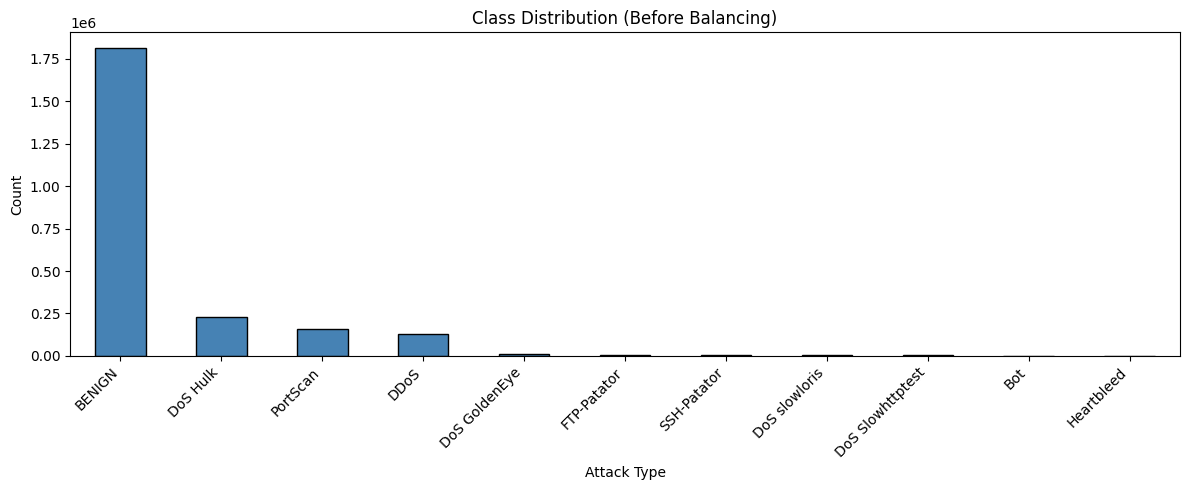

In [44]:
df.columns = df.columns.str.strip()

LABEL_COL = 'Label'

print("--- CLASS DISTRIBUTION---")
label_counts = df[LABEL_COL].value_counts()
print(label_counts)
print(f"\nTotal classes : {df[LABEL_COL].nunique()}")

# deleting the columns for heartbleed
# Remove Heartbleed immediately after loading
before = len(df)
df = df[df[LABEL_COL].str.strip() != 'Heartbleed'].copy()
print(f"Heartbleed rows removed : {before - len(df)}")
print(f"Remaining rows          : {len(df)}")
print(f"Remaining classes       : {df[LABEL_COL].str.strip().nunique()}")
print(df[LABEL_COL].str.strip().value_counts())


# Plot
plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution (Before Balancing)')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#clean the data

In [45]:
print(f"Shape before cleaning: {df.shape}")

# strip the white spaces from the srings
df[LABEL_COL] = df[LABEL_COL].str.strip()

# replace infinity with nan
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop columns with more than 50% missing
before = df.shape[1]
df = df[df.columns[df.isnull().mean() < 0.5]]
print(f"Dropped {before - df.shape[1]} high-missing columns")

# 4. Drop constant columns (zero variance)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)
print(f"Dropped {len(constant_cols)} constant columns: {constant_cols}")

# 5. Drop duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {before - len(df)} duplicate rows")

# 6. Drop the source_file tracking column before modeling
df.drop(columns=['source_file'], inplace=True, errors='ignore')

print(f"\nShape after cleaning: {df.shape}")

Shape before cleaning: (2371704, 75)
Dropped 0 high-missing columns
Dropped 0 constant columns: []
Dropped 0 duplicate rows

Shape after cleaning: (2371704, 75)


#Missing values audit

                missing_count  missing_pct
Flow Bytes/s             2521     0.106295
Flow Packets/s           2521     0.106295


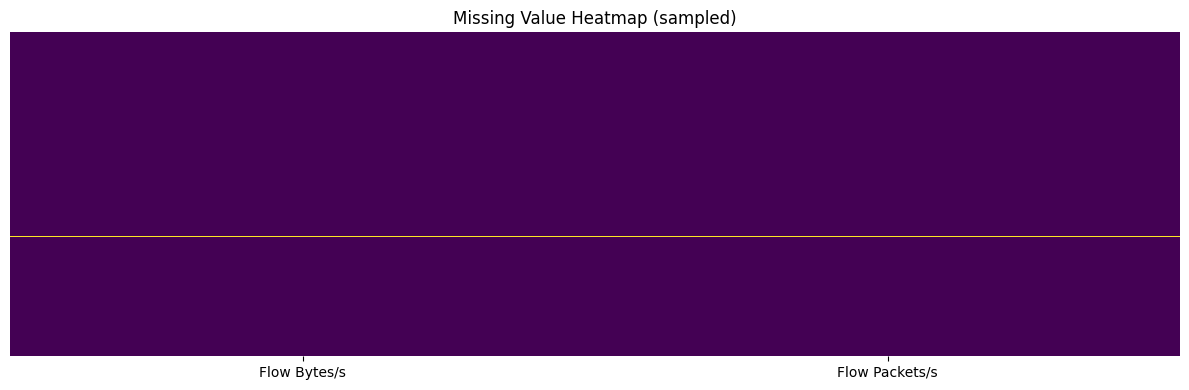

In [46]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count' : missing,
    'missing_pct' : missing_pct
}).query('missing_count > 0')
missing_df.sort_values('missing_pct', ascending=False)

print(missing_df)

#Heatmap of missing values
if not missing_df.empty:
    plt.figure(figsize=(12, 4))
    sns.heatmap(df[missing_df.index].isnull().sample(min(5000, len(df))),
                cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missing Value Heatmap (sampled)')
    plt.tight_layout()
    plt.show()


#separate features and labels then split

In [47]:
# Separate features and target
X = df.drop(columns=[LABEL_COL])
y = df[LABEL_COL]

#keep onlynumeric features

X = X.select_dtypes(include=[np.number])
print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution:\n{y.value_counts()}")

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nEncoded label distribution:\n{pd.Series(y_encoded).value_counts()}")

for cls, idx in zip(le.classes_, le.transform(le.classes_)):
  print(f"{idx} : {cls}")

  # saved the encoder to joblib

# joblib.dump(le, 'content/drive/MyDrive/CICICDS/label_encoder.pkl')

# Train/test split — BEFORE any imputation or scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # preserve class balance in split
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Feature matrix shape: (2371704, 70)
Label distribution:
Label
BENIGN              1816286
DoS Hulk             231072
PortScan             158930
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1966
Name: count, dtype: int64

Encoded label distribution:
0    1816286
4     231072
8     158930
2     128027
3      10293
7       7938
9       5897
6       5796
5       5499
1       1966
Name: count, dtype: int64
0 : BENIGN
1 : Bot
2 : DDoS
3 : DoS GoldenEye
4 : DoS Hulk
5 : DoS Slowhttptest
6 : DoS slowloris
7 : FTP-Patator
8 : PortScan
9 : SSH-Patator

Train size: (1897363, 70), Test size: (474341, 70)


In [48]:
print("=== Split Distribution Check ===")
print(f"Total dataset size : {len(X)}")
print(f"Train size         : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test size          : {X_test.shape[0]}  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Total features     : {X_train.shape[1]}")

print("\n=== Class Distribution in Train Set ===")
train_unique, train_counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.inverse_transform(train_unique), train_counts):
    pct = cnt / len(y_train) * 100
    print(f"  {cls:<25} : {cnt:>7} ({pct:.2f}%)")

print("\n=== Class Distribution in Test Set ===")
test_unique, test_counts = np.unique(y_test, return_counts=True)
for cls, cnt in zip(le.inverse_transform(test_unique), test_counts):
    pct = cnt / len(y_test) * 100
    print(f"  {cls:<25} : {cnt:>7} ({pct:.2f}%)")

print("\n=== Stratification Check ===")
print("Verifying class ratios are preserved across splits...")
for cls_idx in train_unique:
    cls_name   = le.inverse_transform([cls_idx])[0]
    train_pct  = (y_train == cls_idx).sum() / len(y_train) * 100
    test_pct   = (y_test  == cls_idx).sum() / len(y_test)  * 100
    diff       = abs(train_pct - test_pct)
    flag       = "✅" if diff < 1.0 else "⚠️  CHECK"
    print(f"  {cls_name:<25} train: {train_pct:.2f}%  test: {test_pct:.2f}%  diff: {diff:.2f}%  {flag}")

=== Split Distribution Check ===
Total dataset size : 2371704
Train size         : 1897363 (80.0%)
Test size          : 474341  (20.0%)
Total features     : 70

=== Class Distribution in Train Set ===
  BENIGN                    : 1453029 (76.58%)
  Bot                       :    1573 (0.08%)
  DDoS                      :  102422 (5.40%)
  DoS GoldenEye             :    8234 (0.43%)
  DoS Hulk                  :  184857 (9.74%)
  DoS Slowhttptest          :    4399 (0.23%)
  DoS slowloris             :    4637 (0.24%)
  FTP-Patator               :    6350 (0.33%)
  PortScan                  :  127144 (6.70%)
  SSH-Patator               :    4718 (0.25%)

=== Class Distribution in Test Set ===
  BENIGN                    :  363257 (76.58%)
  Bot                       :     393 (0.08%)
  DDoS                      :   25605 (5.40%)
  DoS GoldenEye             :    2059 (0.43%)
  DoS Hulk                  :   46215 (9.74%)
  DoS Slowhttptest          :    1100 (0.23%)
  DoS slowloris      

In [50]:
import os
import numpy as np
import joblib

# Base directory in Google Drive
BASE = '/content/drive/MyDrive/CICIDS/processed_data/'

# 🔥 Create folder if it doesn't exist
os.makedirs(BASE, exist_ok=True)

# -------------------------
# Save data arrays
# -------------------------
np.save(os.path.join(BASE, 'X_train.npy'), X_train.values)
np.save(os.path.join(BASE, 'X_test.npy'),  X_test.values)
np.save(os.path.join(BASE, 'y_train.npy'), y_train)
np.save(os.path.join(BASE, 'y_test.npy'),  y_test)

# -------------------------
# Save label encoder
# -------------------------
joblib.dump(le, os.path.join(BASE, 'label_encoder.pkl'))

# -------------------------
# Save feature names
# -------------------------
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, os.path.join(BASE, 'feature_names.pkl'))

# -------------------------
# Confirm save
# -------------------------
print("✅ Saved cleanly to Google Drive folder:")
print(f"📁 Location: {BASE}")

print(f"\nX_train.npy        — {X_train.shape}")
print(f"X_test.npy         — {X_test.shape}")
print(f"y_train.npy        — {y_train.shape}")
print(f"y_test.npy         — {y_test.shape}")
print(f"label_encoder.pkl  — {len(le.classes_)} classes")
print(f"feature_names.pkl  — {len(feature_names)} features")

print("\nClasses saved:", list(le.classes_))

✅ Saved cleanly to Google Drive folder:
📁 Location: /content/drive/MyDrive/CICIDS/processed_data/

X_train.npy        — (1897363, 70)
X_test.npy         — (474341, 70)
y_train.npy        — (1897363,)
y_test.npy         — (474341,)
label_encoder.pkl  — 10 classes
feature_names.pkl  — 70 features

Classes saved: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator']
